In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
features_final = pd.read_csv("../../../data/extracted_features_extended_mean_blood.csv")
train_groups = ['a', 'b', 'c', 'd']
train_features = features_final[features_final['group_id'].isin(train_groups)]
testing_features = features_final[features_final['group_id']== "e"]
feature_cols = ["Asymmetry", "Compactness", "Convexity", "Multicolor", "red_pixels", "blue_pixels", "mean_red", "mean_blue", "Entropy", "Hue_Var", "Sat_Var", "Val_Var", "hair_feature", "blood_pixels", "blood_detected"]

train_df = train_features[feature_cols + ["Class"]].copy()
train_df["label"] = train_df["Class"].astype(int)
train_df = train_df.drop(columns=["Class"])


In [2]:
#all features

In [ ]:

# Training data (groups a–d)
X_train = train_features[feature_cols].values
y_train = train_features["Class"].astype(int).values
groups_train = train_features["group_id"].values   # a, b, c, d

# Testing data (group e)
X_test = testing_features[feature_cols].values
y_test = testing_features["Class"].astype(int).values

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, GridSearchCV
import numpy as np


rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [ ]:

pipe = Pipeline([
    ("rf", rf)
])


In [ ]:

param_grid = {
    "rf__n_estimators": [200, 300, 500],
    "rf__max_depth": [None, 5, 10, 20],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4]
}

In [ ]:

cv = GroupKFold(n_splits=4)

In [ ]:

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=2,
    error_score=np.nan
)

grid.fit(X_train, y_train, groups=groups_train)

print("Best parameters:", grid.best_params_)
print("Best CV F1 score:", grid.best_score_)

Fitting 4 folds for each of 108 candidates, totalling 432 fits
[CV] END rf__max_depth=None, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=200; total time=   0.4s
[CV] END rf__max_depth=None, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=200; total time=   0.4s
[CV] END rf__max_depth=None, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=200; total time=   0.4s
[CV] END rf__max_depth=None, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=300; total time=   0.5s
[CV] END rf__max_depth=None, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=300; total time=   0.6s
[CV] END rf__max_depth=None, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=200; total time=   0.6s
[CV] END rf__max_depth=None, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=300; total time=   0.6s
[CV] END rf__max_depth=None, rf__min_samples_leaf=1, rf__min_samples_split=5, rf__n_estimators=200; tota

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]


In [10]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

def print_metrics(y_test, y_pred, y_prob):
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1 Score: {f1:.4f}")

print_metrics(y_test, y_pred, y_prob)

Accuracy: 0.4799
Recall: 0.6615
AUC: 0.4673
Precision: 0.5019
F1 Score: 0.5708


In [ ]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


print("\nClassification Report:")
print(classification_report(y_test, y_pred))


print("\nAUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[ 50 128]
 [ 66 129]]

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.28      0.34       178
           1       0.50      0.66      0.57       195

    accuracy                           0.48       373
   macro avg       0.47      0.47      0.46       373
weighted avg       0.47      0.48      0.46       373


AUC: 0.46732929991356953


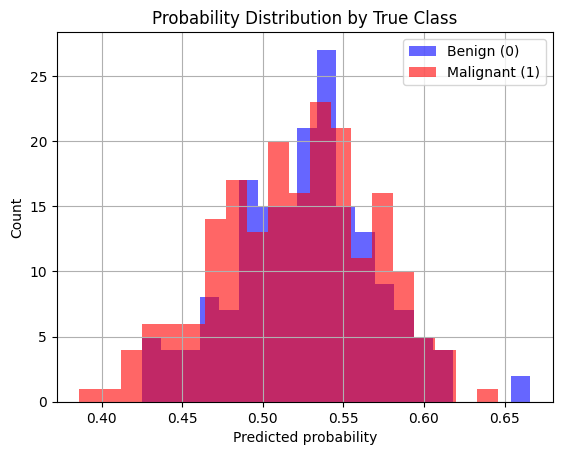

In [12]:
malignant_probs = y_prob[y_test == 1]
benign_probs = y_prob[y_test == 0]

plt.hist(benign_probs, bins=20, alpha=0.6, label="Benign (0)", color="blue")
plt.hist(malignant_probs, bins=20, alpha=0.6, label="Malignant (1)", color="red")

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Probability Distribution by True Class")
plt.legend()
plt.grid(True)
plt.show()


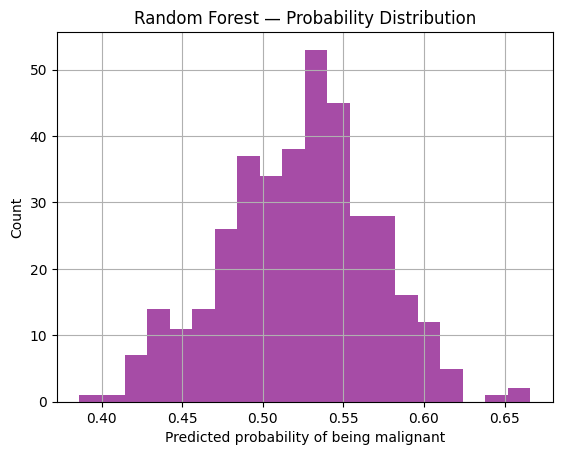

In [13]:
import matplotlib.pyplot as plt

plt.hist(y_prob, bins=20, color='purple', alpha=0.7)
plt.xlabel("Predicted probability of being malignant")
plt.ylabel("Count")
plt.title("Random Forest — Probability Distribution")
plt.grid(True)
plt.show()


In [14]:
#select the best features

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
import numpy as np


best_model = grid.best_estimator_
rf = best_model.named_steps["rf"]

importances = rf.feature_importances_


feature_ranking = sorted(
    zip(feature_cols, importances),
    key=lambda x: x[1],
    reverse=True
)


results = []

for k in range(1, len(feature_cols) + 1):
    top_k_features = [feat for feat, imp in feature_ranking[:k]]
    
    X_train_k = train_features[top_k_features].values
    X_test_k = testing_features[top_k_features].values
    
    rf_k = RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )
    
    rf_k.fit(X_train_k, y_train)
    y_prob_k = rf_k.predict_proba(X_test_k)[:, 1]
    
    auc_k = roc_auc_score(y_test, y_prob_k)
    f1_k = f1_score(y_test, (y_prob_k >= 0.5).astype(int))
    
    results.append((k, auc_k, f1_k))


results = np.array(results, dtype=object)


best_idx = np.argmax(results[:, 1])
best_k = results[best_idx, 0]
best_auc = results[best_idx, 1]
best_f1 = results[best_idx, 2]

print("Best k:", best_k)
print("Best AUC:", best_auc)
print("Best F1:", best_f1)


final_features = [feat for feat, imp in feature_ranking[:best_k]]
print("Selected features:", final_features)


Best k: 8
Best AUC: 0.4955632382598675
Best F1: 0.5594405594405595
Selected features: ['mean_red', 'mean_blue', 'hair_feature', 'Convexity', 'Val_Var', 'Compactness', 'Sat_Var', 'Hue_Var']


In [ ]:

X_train_final = train_features[final_features].values
X_test_final = testing_features[final_features].values


rf_final = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_final, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
y_prob_final = rf_final.predict_proba(X_test_final)[:, 1]



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


y_pred_final = (y_prob_final >= 0.5).astype(int)



In [19]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

def print_metrics(y_test, y_pred, y_prob):
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1 Score: {f1:.4f}")

print_metrics(y_test, y_pred_final, y_prob_final)

Accuracy: 0.4933
Recall: 0.6154
AUC: 0.4956
Precision: 0.5128
F1 Score: 0.5594


In [20]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

print("\nAUC:", roc_auc_score(y_test, y_prob_final))


Confusion Matrix:
[[ 64 114]
 [ 75 120]]

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.36      0.40       178
           1       0.51      0.62      0.56       195

    accuracy                           0.49       373
   macro avg       0.49      0.49      0.48       373
weighted avg       0.49      0.49      0.49       373


AUC: 0.4955632382598675


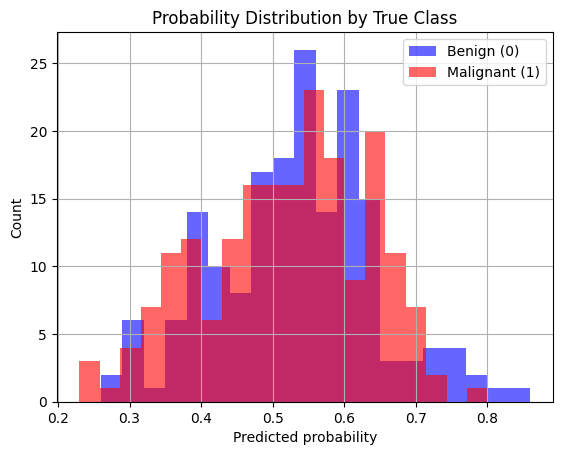

In [21]:
malignant_probs = y_prob_final[y_test == 1]
benign_probs = y_prob_final[y_test == 0]

plt.hist(benign_probs, bins=20, alpha=0.6, label="Benign (0)", color="blue")
plt.hist(malignant_probs, bins=20, alpha=0.6, label="Malignant (1)", color="red")

plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Probability Distribution by True Class")
plt.legend()
plt.grid(True)
plt.show()